In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Load Data**

In [65]:
file_path = '/content/drive/MyDrive/Analisis/Dataset_LeveLearn_UX Honeycomb.csv'

data = pd.read_csv(file_path, encoding='latin-1')
data.head(10)

,Timestamp,Nama Lengkap,Nim,Angkatan,Useful_Q1,Useful_Q2,Useful_Q3,Useful_Q4,Useful_Q5,Useful_Q6,...,Valuable_Q11,Valuable_Q12,Qualitative_Q1,Qualitative_Q2,Qualitative_Q3,Qualitative_Q4,Qualitative_Q5,Feedback,Errors,Suggestion
0,09/03/2026 15:25:16,David Lodewick Simbolon,11S24001,2024,5,4,5,5,4,5,...,5,4,"ya, karna fitur gamafikasi nya membuat kita ti...",mudah sekali,"sudah sangat bagus, apalagi warna nya yang san...","lumayan sulit, saya harus meminta bantuan tema...","yaa, karna ada motivasi berupa leaderboard.","sudah sangat bagus, tapi ada beberapa question...","question kosong, essay yang sangat kontroversi...","sudah bagus, tapi perbaiki yang di bagian ques..."
1,09/03/2026 15:27:52,Edwin Christoffel Lumbantobing,11S24002,2024,5,5,5,5,5,5,...,4,4,Iya sangat mendukung karena dapat meningkatkan...,Mudah dimudahkan karena petunjuk dari sistem i...,Tampilan sudah cukup oke dan untuk daya tarikn...,"Mudah,setelah kita menjawab soal kita dapat la...","Iya lumayan meningkatkan,biasanya saya belajar...",Saya sangat senang menggunakan aplikasi terseb...,Error mungkin dibagian beberapa ada bagian mat...,Saran saya untuk bagian undo jawaban atau kemb...
2,09/03/2026 15:27:08,Aditya putera Keliat,11S24003,2024,4,4,4,4,4,4,...,3,3,"Berguna, agar aplikasi tidak terlalu membosank...",Mudah digunakan,Cukup menarik,Mudah ditemukan \nDisaat selesai mengerjakan a...,Cukup membantu dari salah satu matkul dengan m...,Sudah lumayan bagus,Terkadang saat mau mengerjakan assessment/tuga...,Menambahkan fitur tema
3,09/03/2026 15:48:06,Gian Danovan,11S24004,2024,4,4,4,4,4,4,...,4,4,sangat mambentu membatu saya tetap fokus dan t...,"sangat mudah di gunakan tanpa halangan, seluru...",untuk tampilan aplikasi sangat menari membuat ...,sangat mudah icon dalam aplikasi sangat mudah ...,sangat membantu sekali,sangattt kerennnn!!!,tidak ada,"tamabahkan gambar pada halaman soal, seperti g..."
4,09/03/2026 15:27:36,Rouli Claudia Panggabean,11S24005,2024,3,3,3,3,3,4,...,4,4,Berguna karena membuat aku jadi termotivasi da...,Mudah,Bagus,Mudah karena tata letak dan desain nya murah d...,Ya karena saya bisa dengan fleksibel mengerjak...,Bagus banget,Tidak ada,Semoga soalnya update tiap minggu ya kak/bangð
5,09/03/2026 15:26:16,Martha Saulina Nababan,11S24006,2024,4,4,4,4,4,4,...,4,5,":Â Ya, fitur gamifikasi sangat berguna dalam m...","Iya, fitur gamifikasinya sangat mudah digunaka...","Menurut saya sangatÂ menarik, karena tampilan ...","Ya, sangat mudah. Fitur-fitur seperti poin dan...","Iya, sangat membantu. Belajar dengan aplikasi ...",Aplikasi ini memiliki tampilan (UI) yang cukup...,Ada level yg tidak ada soal nya dan juga jawab...,Berikan pengingat atau pemberitahuan otomatis ...
6,09/03/2026 15:31:35,Miftahul jannah Siregar,11S24007,2024,5,4,4,5,4,5,...,5,3,"Menurut saya iya,karena dengan ada nya fitur g...","Menurut saya mudah digunakan,tapi masih ada be...","Menurut saya tampilannya kurang menarik,di bag...","Sejauh ini saya mudah menemukan fiturnya,exper...","Menurut saya ini membantu,karena setelah mater...","Feedback saya dari aplikasi ini,agar tampilann...",Temuan error pada aplikasi adalah:\n1.kuci jaw...,Saran saya agar interfacenya lebih dibuat mena...
7,09/03/2026 15:21:13,DEA MARANATA SIREGAR,11S24008,2024,4,4,4,4,4,4,...,4,4,Sangat berguna karna ada Leaderboard nya sehin...,Mudah,Sudah bagus,"Mudah, saya langsung mengerti fitur2nya dan ke...","Iya, sangat. Menurut saya tanpa aplikasi ini s...",Aplikasinya sudah bagus.,Tidak ada,Tolong kakak Abang menambahkan matkul lainnya ...
8,09/03/2026 15:28:30,Sandrina Trianisa Sihite,11S24009,2024,4,4,4,4,4,4,...,5,4,"Ya, sistem pembelajaran dengan gamifikasi tent...",Fitur gamifikasi mudah digunakan,Tampilannya dapat dilihat dan diakses dengan m...,"Ya. Sesudah membaca/membahas suatu materi, aka...",Ya. Aplikasi ini membantu meningkatkan pengala...,Aplikasi over all sudah berjalan dengan baik d...,"Terkadang, jika baru masuk ke aplikasi. Inform...",Dapat memuat soal soal yang lebih banyak dalam...

**2. Pre-processing**

In [66]:
metrics = ['Useful', 'Usable', 'Desirable', 'Findable', 'Accessible', 'Credible', 'Valuable']
likert_columns = [f"{metric}_Q{i}" for metric in metrics for i in range(1, 13)]

print(f"Jumlah baris sebelum hapus duplikat: {data.shape[0]}")
data = data.drop_duplicates(subset=['Nim'], keep='last').copy()
print(f"Jumlah baris setelah hapus duplikat: {data.shape[0]}\n")

df_likert = data[likert_columns].astype(float)
df_likert["Total_Score"] = df_likert.sum(axis=1)

Jumlah baris sebelum hapus duplikat: 54
Jumlah baris setelah hapus duplikat: 54



In [67]:
# Cek missing values
missing_values = df_likert.isnull().sum().sum()
if missing_values > 0:
    df_likert = df_likert.dropna()
    data = data.loc[df_likert.index]
    print(f"Missing values ditemukan: {missing_values}. Baris telah dihapus.\n")
else:
    print("Tidak ada missing values yang ditemukan.\n")

# Deteksi straight-lining (jawaban konstan)
df_likert['Std_Dev'] = df_likert[likert_columns].std(axis=1)
straight_liners = df_likert[df_likert['Std_Dev'] == 0]
print(f"Jumlah responden terindikasi straight-lining: {len(straight_liners)}\n")

# Menghitung Rata-rata per Dimensi
for metric in metrics:
    cols = [col for col in likert_columns if metric in col]
    df_likert[f'{metric}_Avg'] = df_likert[cols].mean(axis=1)

Tidak ada missing values yang ditemukan.

Jumlah responden terindikasi straight-lining: 0



**3.  Skor Rata-rata per Dimensi**

In [75]:
dimensions = {
    'Useful': [f'Useful_Q{i}' for i in range(1, 13)],
    'Usable': [f'Usable_Q{i}' for i in range(1, 13)],
    'Desirable': [f'Desirable_Q{i}' for i in range(1, 13)],
    'Findable': [f'Findable_Q{i}' for i in range(1, 13)],
    'Accessible': [f'Accessible_Q{i}' for i in range(1, 13)],
    'Credible': [f'Credible_Q{i}' for i in range(1, 13)],
    'Valuable': [f'Valuable_Q{i}' for i in range(1, 13)]
}

for dim, cols in dimensions.items():
    data[f'{dim}_Avg'] = data[cols].mean(axis=1)

avg_cols = [f'{dim}_Avg' for dim in dimensions.keys()]
df_analysis = data[avg_cols]

summary_stats = df_analysis.describe().T
summary_stats = summary_stats[['mean', 'std', 'min', 'max']]
summary_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
summary_stats.index = [dim for dim in dimensions.keys()]

summary_stats = summary_stats.sort_values(by='Mean', ascending=False)

**4. Visualisasi**

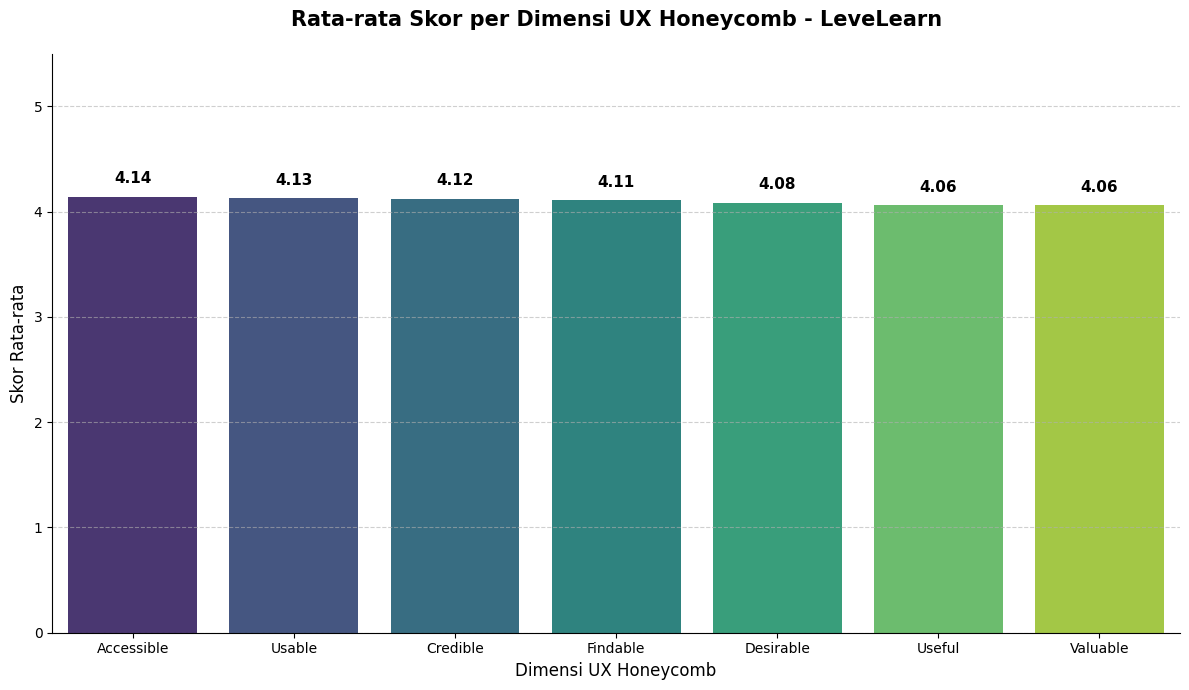

=== ANALISIS KUANTITATIF: SKOR RATA-RATA PER DIMENSI ===
                Mean   Std Dev       Min       Max
Accessible  4.143519  0.539677  2.416667  5.000000
Usable      4.126543  0.463200  2.750000  5.000000
Credible    4.120370  0.440859  2.916667  5.000000
Findable    4.109568  0.447103  3.000000  5.000000
Desirable   4.083333  0.508059  2.250000  4.833333
Useful      4.061728  0.499786  2.750000  5.000000
Valuable    4.061728  0.521092  2.083333  5.000000


In [76]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=summary_stats.index,
    y='Mean',
    data=summary_stats,
    hue=summary_stats.index,
    palette='viridis',
    legend=False
)

plt.ylim(0, 5.5)
plt.title('Rata-rata Skor per Dimensi UX Honeycomb - LeveLearn', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Skor Rata-rata', fontsize=12)
plt.xlabel('Dimensi UX Honeycomb', fontsize=12)

for i, v in enumerate(summary_stats['Mean']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("=== ANALISIS KUANTITATIF: SKOR RATA-RATA PER DIMENSI ===")
print(summary_stats)